# CAN Bus Anomaly Detection - Autoencoder + LSTM Autoencoder (set_01)

Unsupervised anomaly detection trained on **normal traffic only** from
`data/set01_train_frames.csv`:
- a **per-frame Autoencoder** (conditional CAN-ID embedding) - baseline with no
  temporal context;
- a **windowed LSTM Autoencoder** over 16 consecutive frames - captures temporal
  structure.

Session-aware: the merged CSV interleaves independent recordings that all share
the same epoch base, so LSTM windows and temporal features (byte deltas,
inter-arrival gaps) are always computed **within one session** - two sessions are
never stitched together.

17-dim per-frame features include a byte-delta (freeze) signal and a gap-ratio
(timing) signal computed against each ID's training-normal median period.

Reconstruction threshold (99th pct) and timing thresholds (p1/p5 of the
validation-NORMAL min gap-ratio) are leak-free. Saves `best_model_lstm.pth`,
`best_model_ae.pth`, `top_can_ids.json`, `id_stats.json`,
`training_history.csv` to the writable output dir (`/kaggle/working` on Kaggle).

In [1]:
import json
import torch
import numpy as np
import pandas as pd
import torch.nn as nn
import torch.nn.functional as F
from pathlib import Path
from torch.utils.data import Dataset, DataLoader
from tqdm.notebook import tqdm

print(f"PyTorch: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")

PyTorch: 2.10.0+cu128
CUDA available: True


In [2]:
# ---- Paths ----
if Path("/kaggle/input").exists():
    DATA_DIR = Path("/kaggle/input/datasets/ed4meee/can-train-frames")
    MODEL_DIR = Path("/kaggle/working/")
else:
    DATA_DIR = Path("data")
    MODEL_DIR = Path("models")

# The Kaggle input mount is READ-ONLY, so every artifact (cache npz, json,
# history csv, model pth) goes to the writable output dir.
WRITE_DIR = MODEL_DIR if Path("/kaggle/input").exists() else DATA_DIR
MODEL_DIR.mkdir(parents=True, exist_ok=True)
WRITE_DIR.mkdir(parents=True, exist_ok=True)

TRAIN_CSV = DATA_DIR / "set01_train_frames.csv"
print(f"Read  : {TRAIN_CSV}")
print(f"Write : {WRITE_DIR}")

# ---- Hyperparameters (matches src/train.py) ----
TOP_K = 64
INPUT_DIM = 17
TRAIN_FRAC = 1.0

WINDOW = 16
LSTM_HIDDEN = 64
LSTM_LAYERS = 1
LSTM_EPOCHS = 50
LSTM_LR = 1e-3
LSTM_PATIENCE = 10
BATCH_SIZE = 256
VAL_RATIO = 0.2
SEED = 42
THRESHOLD_PCT = 99
TIMING_PCTS = (1, 5)

BYTE_COLS = [f"byte_{i}" for i in range(8)]
CACHE_NPZ = WRITE_DIR / "ae_data.npz"


def set_seed(seed=SEED):
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    np.random.seed(seed)


def fit_top_ids(can_ids, k=TOP_K):
    counts = pd.Series(can_ids).value_counts()
    top = counts.head(k).index.tolist()
    print(f"Top-{k} IDs: {top[:5]} ... ({len(top)} total)")
    return top


def can_ids_to_indices(can_ids, top_ids):
    id_map = {cid: i for i, cid in enumerate(top_ids)}
    return np.array([id_map.get(cid, len(top_ids)) for cid in can_ids], dtype=np.int32)

Read  : /kaggle/input/datasets/ed4meee/can-train-frames/set01_train_frames.csv
Write : /kaggle/working


## Features (17 dims per frame)

| # | Feature            | Source                                          |
|---|--------------------|-------------------------------------------------|
| 0 | expected_period    | median inter-arrival (ms) / 1000, capped <= 1.0 |
| 1 | typical_dlc        | mode(DLC) / 8                                    |
| 2 | payload_variance   | mean per-byte std over real bytes, / 0.3 clipped |
| 3 | frequency_rank     | log(1+count) / log(1+max_count)                  |
| 4 | byte_0 .. 11       | payload bytes / 255                              |
| 12| DLC                | DLC / 8                                          |
| 13| byte_delta_mean_abs| mean |delta| vs prev same-(Session,ID) frame     |
| 14| byte_delta_std     | std of the 8 byte deltas                         |
| 15| gap_lo             | min(gap / period, 1): 1 normal -> 0 flood        |
| 16| gap_hi             | min(period / gap, 1): 1 normal -> 0 flood/long   |

Stats are fit on **training-normal rows only** (no leak); unseen IDs fall back to
the global average. Deltas and gaps are computed on the FULL stream (attack rows
included) but always within one session, so a replayed payload still shows its
freeze signal. All thresholds are calibrated on **validation-normal windows only**.

In [3]:
class LSTMAutoencoder(nn.Module):
    # Sequence autoencoder over (W, F) windows of consecutive frames.
    # Encoder LSTM -> last hidden state -> repeated -> decoder LSTM -> reconstruction.
    def __init__(self, input_dim=INPUT_DIM, hidden=LSTM_HIDDEN, num_layers=LSTM_LAYERS):
        super().__init__()
        self.input_dim = input_dim
        self.hidden = hidden
        self.num_layers = num_layers
        self.encoder = nn.LSTM(input_dim, hidden, num_layers, batch_first=True)
        self.decoder = nn.LSTM(hidden, input_dim, num_layers, batch_first=True)

    def forward(self, x):
        _, (h, _) = self.encoder(x)
        z = h[-1].unsqueeze(1).repeat(1, x.size(1), 1)
        out, _ = self.decoder(z)
        return out

    @torch.no_grad()
    def get_reconstruction_error(self, x):
        self.eval()
        recon = self.forward(x)
        return F.mse_loss(recon, x, reduction="none").mean(dim=(1, 2))

In [4]:
# ---- Per-ID behavioral stats (training-normal rows only, no leak) ----
PERIOD_CAP_MS = 1000.0
VAR_CAP = 0.3
GAP_CAP_MS = 10.0


def _normalize_period_ms(median_gap_ms):
    return float(min(median_gap_ms / PERIOD_CAP_MS, 1.0)) if np.isfinite(median_gap_ms) else 1.0


def fit_id_stats(df):
    # Per-ID stats from a normal-only DataFrame: [expected_period, typical_dlc,
    # payload_variance, frequency_rank, median_dmean, median_gap_ms].
    # Inter-arrival gaps and byte deltas are computed WITHIN each session only -
    # the merged CSV interleaves independent recordings (all start at the same
    # epoch second), so a global chronological sort must never produce neighbors.
    df = df.copy()
    df["raw_dlc"] = (df["DLC"] * 8).round().astype(int)
    counts = df["CAN_ID"].value_counts()
    max_count = counts.max()

    stats = {}
    byte_arr = df[BYTE_COLS].values
    dlc_arr = df["raw_dlc"].values
    ts_arr = df["Timestamp"].values

    for cid, grp_idx in df.groupby("CAN_ID").groups.items():
        idx = grp_idx.to_numpy()
        g = df.loc[idx]

        gap_parts, dmean_parts = [], []
        if "Session" in df.columns:
            for _, sub in g.groupby("Session", sort=False):
                sub = sub.sort_values("Timestamp")
                if len(sub) < 2:
                    continue
                ts = sub["Timestamp"].values
                sg = np.diff(ts)
                sg = sg[sg > 1e-6]
                gap_parts.append(sg)
                gb = sub[BYTE_COLS].values
                dmean_parts.append(np.abs(np.diff(gb, axis=0)).mean(axis=1))
        else:
            ts = g["Timestamp"].values
            sg = np.diff(ts)
            sg = sg[sg > 1e-6]
            gap_parts.append(sg)
            if len(idx) > 1:
                dmean_parts.append(np.abs(np.diff(byte_arr[idx], axis=0)).mean(axis=1))

        gaps = np.concatenate(gap_parts) if gap_parts else np.array([], dtype=np.float64)
        period = np.median(gaps) * 1e3 if len(gaps) else float("nan")

        dlc_mode = g["raw_dlc"].mode().iloc[0]

        gb = byte_arr[idx]
        gd = dlc_arr[idx]
        stds = []
        for i in range(8):
            m = gd > i
            if m.sum() > 1:
                stds.append(gb[m, i].std())
        variance = float(np.mean(stds)) if stds else 0.0

        rank = np.log1p(counts[cid]) / np.log1p(max_count)

        dmeans = np.concatenate(dmean_parts) if dmean_parts else np.array([], dtype=np.float64)
        median_dmean = float(np.median(dmeans)) if len(dmeans) else float("nan")
        median_gap_ms = float(np.median(gaps) * 1e3) if len(gaps) else float("nan")

        stats[str(cid)] = [
            _normalize_period_ms(period),
            float(dlc_mode) / 8.0,
            float(min(variance / VAR_CAP, 1.0)),
            float(rank),
            median_dmean,
            median_gap_ms,
        ]

    global_avg = [float(np.nanmean([s[i] for s in stats.values()])) for i in range(6)]
    for cid in stats:
        for i in range(6):
            v = stats[cid][i]
            if not np.isfinite(v):
                stats[cid][i] = global_avg[i]
    return stats, global_avg


def save_id_stats(stats, global_avg):
    payload = dict(stats)
    payload["global_avg"] = global_avg
    path = WRITE_DIR / "id_stats.json"
    with open(path, "w") as f:
        json.dump(payload, f, indent=2)
    print(f"Saved id_stats: {len(stats)} IDs + global_avg -> {path}")


def build_features(can_ids, payload, stats, global_avg):
    # Resolve per-ID stats into a (N, 4) matrix (unseen -> global_avg), then
    # hstack with the (N, 9) payload [byte_0..7, DLC].
    n = len(can_ids)
    vec = np.tile(np.asarray(global_avg[:4], dtype=np.float32), (n, 1))

    table = {str(cid): np.asarray(v, dtype=np.float32) for cid, v in stats.items()}
    keys = np.array(sorted(table.keys()), dtype=object)
    table_mat = np.stack([table[k][:4] for k in keys]).astype(np.float32)
    query = np.asarray(can_ids, dtype=object)
    loc = np.searchsorted(keys, query)
    loc = np.clip(loc, 0, len(keys) - 1)
    known = keys[loc] == query
    vec[known] = table_mat[loc[known]]

    return np.hstack([vec, payload.astype(np.float32)]).astype(np.float32)


class ByteDeltaRoller:
    # Rolling byte-delta ("freeze signal") features, chunk-safe. For each frame,
    # byte delta = current 8 bytes - previous same-(Session, ID) frame, computed
    # over the FULL stream (attack frames included). Summarized over the "real"
    # bytes only (index < raw DLC): [byte_delta_mean_abs, byte_delta_std].
    # First occurrence of an ID in a session (no predecessor) -> [0, 0].

    def __init__(self):
        self.last = {}

    def advance(self, df):
        ids = df["CAN_ID"].astype(str).values
        b = df[BYTE_COLS].values.astype(np.float32)
        dlc = (df["DLC"].values * 8).round().astype(np.int64)
        n = len(df)

        if "Session" in df.columns:
            sess = df["Session"].astype(str).values
            prev = pd.DataFrame(b).groupby(
                [pd.Series(sess), pd.Series(ids)], sort=False
            ).shift(1).values.astype(np.float32)
        else:
            prev = pd.DataFrame(b).groupby(pd.Series(ids), sort=False).shift(1).values.astype(np.float32)
        is_first = np.isnan(prev).all(axis=1)

        d = np.zeros((n, 8), dtype=np.float32)
        nz = ~is_first
        d[nz] = b[nz] - prev[nz]

        # carry the last payload per (session, id) across chunk boundaries
        if "Session" in df.columns:
            for (s, cid), gi in df.groupby(["Session", "CAN_ID"], sort=False).indices.items():
                i0, ilast = gi[0], gi[-1]
                if is_first[i0] and (s, cid) in self.last:
                    d[i0] = b[i0] - self.last[(s, cid)]
                self.last[(s, cid)] = b[ilast]
        else:
            for cid in pd.unique(ids):
                if cid in self.last:
                    m = (ids == cid) & is_first
                    if m.any():
                        d[m] = b[m] - self.last[cid]
                self.last[cid] = b[ids == cid][-1]

        real = dlc[:, None] > np.arange(8)
        n_real = real.sum(axis=1)
        ad = np.where(real, np.abs(d), 0.0)
        d2 = np.where(real, d, 0.0)
        mean_abs = ad.sum(axis=1) / np.maximum(n_real, 1)
        with np.errstate(invalid="ignore"):
            mean_sq = (d2 * d2).sum(axis=1) / np.maximum(n_real, 1)
            std = np.sqrt(np.clip(mean_sq - mean_abs ** 2, 0, None))
        mean_abs = np.where(n_real > 0, mean_abs, 0.0)
        std = np.where(n_real > 1, std, 0.0)
        return np.column_stack([mean_abs, std]).astype(np.float32)


class GapRoller:
    # Per-frame inter-arrival gap (ms) vs the previous same-(Session, ID) frame.
    # NaN for the first occurrence of an ID in a session. Chunk-safe: the last
    # Timestamp per (Session, ID) is carried across chunk boundaries.

    def __init__(self):
        self.last_ts = {}

    def advance(self, df):
        n = len(df)
        ids = df["CAN_ID"].astype(str).values
        ts = df["Timestamp"].values.astype(np.float64)

        if "Session" in df.columns:
            sess = df["Session"].astype(str).values
            prev = pd.Series(ts).groupby(
                [pd.Series(sess), pd.Series(ids)], sort=False
            ).shift(1).values.astype(np.float64)
        else:
            prev = pd.Series(ts).groupby(pd.Series(ids), sort=False).shift(1).values.astype(np.float64)
        has_prev = ~np.isnan(prev)
        gap = np.full(n, np.nan, dtype=np.float64)
        gap[has_prev] = (ts[has_prev] - prev[has_prev]) * 1e3

        # carry the last timestamp per (session, id) across chunk boundaries
        if "Session" in df.columns:
            for (s, cid), gi in df.groupby(["Session", "CAN_ID"], sort=False).indices.items():
                i0 = gi[0]
                if not has_prev[i0] and (s, cid) in self.last_ts:
                    gap[i0] = (ts[i0] - self.last_ts[(s, cid)]) * 1e3
                self.last_ts[(s, cid)] = ts[gi[-1]]
        else:
            for cid in pd.unique(ids):
                idx = np.flatnonzero(ids == cid)
                if idx.size == 0:
                    continue
                i0 = idx[0]
                if not has_prev[i0] and cid in self.last_ts:
                    gap[i0] = (ts[i0] - self.last_ts[cid]) * 1e3
                self.last_ts[cid] = ts[idx[-1]]

        return gap.astype(np.float32)


def normalize_gap_ratios(gap_ms, can_ids, stats, global_avg):
    # Map per-frame gap_ms to [0,1] gap features vs each ID's expected period
    # (training-normal median inter-arrival, stat idx 5; unseen -> global_avg).
    # First frames (gap NaN) -> [1.0, 1.0] (no anomaly evidence yet).
    #   gap_lo = min(gap / period, 1)     -> 1.0 normal, ->0 flood
    #   gap_hi = min(period / gap, 1)     -> 1.0 normal, ->0 flood OR long gap
    n = len(can_ids)
    fallback = float(global_avg[5]) if np.isfinite(global_avg[5]) else 1.0
    if not np.isfinite(fallback) or fallback <= 0:
        fallback = 1.0

    table = {str(cid): float(v[5]) for cid, v in stats.items()}
    keys = np.array(sorted(table.keys()), dtype=object)
    mat = np.array([table[k] for k in keys], dtype=np.float64)
    query = np.asarray(can_ids, dtype=object)
    loc = np.clip(np.searchsorted(keys, query), 0, len(keys) - 1)
    period = mat[loc]
    period[keys[loc] != query] = fallback
    period[~np.isfinite(period)] = fallback
    period[period <= 0] = fallback

    gap = np.asarray(gap_ms, dtype=np.float64)
    gap_lo = np.minimum(gap / period, 1.0)
    gap_hi = np.minimum(period / np.maximum(gap, 1e-3), 1.0)
    gap_lo = np.where(np.isnan(gap_lo), 1.0, gap_lo)
    gap_hi = np.where(np.isnan(gap_hi), 1.0, gap_hi)
    return np.column_stack([gap_lo, gap_hi]).astype(np.float32)

In [5]:
def make_windows(feats, sessions, window=WINDOW):
    # Non-overlapping windows built PER-SESSION: a window never spans two
    # independent recordings that share the same epoch base.
    parts = []
    for s in np.unique(sessions):
        f = feats[sessions == s]
        n = (len(f) // window) * window
        if n:
            parts.append(f[:n].reshape(-1, window, f.shape[1]))
    return np.concatenate(parts)


class WindowDataset(Dataset):
    def __init__(self, windows):
        self.windows = torch.tensor(windows, dtype=torch.float32)

    def __len__(self):
        return len(self.windows)

    def __getitem__(self, idx):
        return self.windows[idx]


# ---- Build the 17-dim dataset from the train CSV (cached) ----
npz_path = CACHE_NPZ
if npz_path.exists():
    with np.load(npz_path, allow_pickle=True) as d:
        if (d.get("version") == 4 and "train_feats" in d and "train_sess" in d
                and "train_idx" in d and "val_idx" in d):
            print("Loading ae_data.npz ...")
            train_w = make_windows(d["train_feats"], d["train_sess"])
            val_w = make_windows(d["val_feats"], d["val_sess"])
            top_ids = d["top_ids"].tolist()
            train_idx = d["train_idx"].astype(np.int32)
            val_idx = d["val_idx"].astype(np.int32)
            print(f"  train windows: {len(train_w):,}  val windows: {len(val_w):,}  "
                  f"(W={WINDOW}, F={d['train_feats'].shape[1]})")

if "train_w" not in dir():
    csv_path = TRAIN_CSV
    if not csv_path.exists():
        raise FileNotFoundError(f"{csv_path} missing. Run parse_can_train_test.py first.")

    # Byte deltas and gaps must be computed per-session over the FULL stream
    # (attack frames included). Rollers carry state across chunk boundaries.
    roller = ByteDeltaRoller()
    gap_roller = GapRoller()
    parts = []
    for ch in tqdm(pd.read_csv(csv_path, chunksize=2_000_000, dtype={"CAN_ID": str}), desc="Chunk"):
        if "Session" in ch.columns:
            ch = ch.sort_values(["Session", "Timestamp"]).reset_index(drop=True)
        else:
            ch = ch.sort_values("Timestamp").reset_index(drop=True)
        delta = roller.advance(ch)
        gap_ms = gap_roller.advance(ch)
        m = ch["attack"].values == 0
        keep = ch.loc[m].copy()
        keep["_delta0"] = delta[m, 0]
        keep["_delta1"] = delta[m, 1]
        keep["_gap_ms"] = gap_ms[m]
        if TRAIN_FRAC < 1.0:
            keep = keep.sample(frac=TRAIN_FRAC, random_state=42)
        parts.append(keep)
    n_df = pd.concat(parts, ignore_index=True)
    print(f"Normal rows kept: {len(n_df):,}")

    n_ids = n_df["CAN_ID"].astype(str).values
    n_bytes = n_df[BYTE_COLS].values.astype(np.float32)
    n_dlc = n_df["DLC"].values.astype(np.float32)

    top_ids = fit_top_ids(n_ids)
    with open(WRITE_DIR / "top_can_ids.json", "w") as f:
        json.dump(top_ids, f)

    stats, global_avg = fit_id_stats(n_df)
    save_id_stats(stats, global_avg)

    payload = np.hstack([n_bytes, n_dlc.reshape(-1, 1)]).astype(np.float32)
    features = build_features(n_ids, payload, stats, global_avg)
    temporal = n_df[["_delta0", "_delta1"]].values.astype(np.float32)
    gap_feats = normalize_gap_ratios(n_df["_gap_ms"].values, n_ids, stats, global_avg)
    features = np.hstack([features, temporal, gap_feats]).astype(np.float32)

    if "Session" in n_df.columns:
        sessions = n_df["Session"].astype(str).values
    else:
        sessions = np.zeros(len(n_df), dtype=object)

    # Per-session chronological split: the last VAL_RATIO of each session's
    # frames are validation (a global-timeline split is meaningless).
    val_mask = np.zeros(len(n_df), dtype=bool)
    if "Session" in n_df.columns:
        for gi in n_df.groupby("Session").indices.values():
            gi = np.asarray(gi)
            n_val = int(len(gi) * VAL_RATIO)
            if n_val:
                val_mask[gi[-n_val:]] = True
    else:
        n_val = int(len(n_df) * VAL_RATIO)
        val_mask[len(n_df) - n_val:] = True

    train_feats, val_feats = features[~val_mask], features[val_mask]
    train_sess, val_sess = sessions[~val_mask], sessions[val_mask]
    train_idx = can_ids_to_indices(n_ids[~val_mask], top_ids)
    val_idx = can_ids_to_indices(n_ids[val_mask], top_ids)

    np.savez_compressed(
        npz_path,
        version=4,
        train_feats=train_feats, train_sess=train_sess, train_idx=train_idx,
        val_feats=val_feats, val_sess=val_sess, val_idx=val_idx,
        top_ids=top_ids,
    )

    train_w = make_windows(train_feats, train_sess)
    val_w = make_windows(val_feats, val_sess)
    print(f"Saved ae_data.npz (train windows: {len(train_w):,}, val windows: {len(val_w):,}, "
          f"feat_dim={INPUT_DIM}, W={WINDOW})")
    print(f"Train sessions: {sorted(pd.unique(train_sess))}")

print(f"windows: train={len(train_w):,} val={len(val_w):,} (W={WINDOW}, F={INPUT_DIM})")

Chunk: 0it [00:00, ?it/s]

Normal rows kept: 10,603,583
Top-64 IDs: ['1E5', '0C5', '0C1', '0F1', '0C9'] ... (51 total)
Saved id_stats: 51 IDs + global_avg -> /kaggle/working/id_stats.json
Saved ae_data.npz (train windows: 530,174, val windows: 132,538, feat_dim=17, W=16)
Train sessions: ['DoS-1', 'DoS-2', 'accessory-1', 'accessory-2', 'attack-free-1', 'attack-free-2', 'force-neutral-1', 'force-neutral-2', 'rpm-1', 'rpm-2', 'standstill-1', 'standstill-2']
windows: train=530,174 val=132,538 (W=16, F=17)


In [6]:
@torch.no_grad()
def compute_threshold(model, loader, device, percentile=THRESHOLD_PCT):
    model.eval()
    all_errs = []
    for x in tqdm(loader, desc="Threshold", leave=False):
        x = x.to(device)
        err = model.get_reconstruction_error(x)
        all_errs.append(err.cpu().numpy())
    all_errs = np.concatenate(all_errs)
    threshold = float(np.percentile(all_errs, percentile))
    print(f"Threshold ({percentile}th pct): {threshold:.6f}")
    return threshold


def compute_timing_threshold(val_w, percentiles=TIMING_PCTS):
    # Anomaly = min_ratio BELOW the threshold (flood/gap -> ~0, normal -> ~1),
    # so thresholds are the LOW percentiles of the VALIDATION-NORMAL min-ratio
    # distribution. min_ratio = min over frames of gap_lo & gap_hi (the last two
    # feature dims), matching evaluate.window_stream. No attack/test scores ever
    # enter this calibration.
    min_ratio = np.minimum(val_w[..., -2].min(axis=1), val_w[..., -1].min(axis=1))
    ths = {}
    for pct in percentiles:
        th = float(np.percentile(min_ratio, pct))
        ths[pct] = th
        print(f"Timing threshold ({pct}th pct of val-normal min-ratio): {th:.6f}")
    return ths


def run_epoch(model, loader, device, optimizer=None, desc=None):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()
    losses = []
    ctx = torch.enable_grad() if is_train else torch.no_grad()
    pbar = tqdm(loader, desc=desc or ("train" if is_train else "val"), leave=False)
    with ctx:
        for x in pbar:
            x = x.to(device)
            recon = model(x)
            loss = torch.nn.functional.mse_loss(recon, x)
            if is_train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
            losses.append(loss.item())
            pbar.set_postfix(loss=f"{loss.item():.6f}")
    return np.mean(losses)

In [7]:
set_seed(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

loader_kw = dict(batch_size=BATCH_SIZE, num_workers=2, pin_memory=True)
train_loader = DataLoader(WindowDataset(train_w), shuffle=True, drop_last=True, **loader_kw)
val_loader = DataLoader(WindowDataset(val_w), **loader_kw)
print(f"Train batches: {len(train_loader)} | Val batches: {len(val_loader)}")

model = LSTMAutoencoder(input_dim=INPUT_DIM, hidden=LSTM_HIDDEN, num_layers=LSTM_LAYERS).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=LSTM_LR, weight_decay=1e-5)
print(f"Parameters: {sum(p.numel() for p in model.parameters()):,}")

print(f"\n{'=' * 60}\nTraining LSTM AE for {LSTM_EPOCHS} epochs (patience={LSTM_PATIENCE})\n{'=' * 60}")

history = {"epoch": [], "train_loss": [], "val_loss": []}
best_val_loss = float("inf")
stale = 0
best_epoch = 0
weights_path = MODEL_DIR / "best_model_lstm_weights.pth"

for epoch in range(1, LSTM_EPOCHS + 1):
    train_loss = run_epoch(model, train_loader, device, optimizer, desc=f"LSTM E{epoch} train")
    val_loss = run_epoch(model, val_loader, device, desc=f"LSTM E{epoch} val")

    history["epoch"].append(epoch)
    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)

    marker = ""
    if val_loss < best_val_loss:
        best_val_loss, best_epoch, stale = val_loss, epoch, 0
        marker = " *"
        torch.save(model.state_dict(), weights_path)
    else:
        stale += 1

    print(f"Epoch {epoch:3d} | Train: {train_loss:.6f} | Val: {val_loss:.6f}{marker}")

    if stale >= LSTM_PATIENCE:
        print(f"\nEarly stopping at epoch {epoch}")
        break

print("\nReloading best weights + computing threshold on validation windows ...")
model.load_state_dict(torch.load(weights_path, map_location=device, weights_only=True))
threshold = compute_threshold(model, val_loader, device, THRESHOLD_PCT)
timing_thresholds = compute_timing_threshold(val_w, TIMING_PCTS)

torch.save({
    "arch": "lstm",
    "epoch": best_epoch,
    "model_state_dict": model.state_dict(),
    "optimizer_state_dict": optimizer.state_dict(),
    "loss": best_val_loss,
    "threshold": threshold,
    "input_dim": INPUT_DIM,
    "hidden": LSTM_HIDDEN,
    "num_layers": LSTM_LAYERS,
    "window": WINDOW,
    "timing_thresholds": {str(p): t for p, t in timing_thresholds.items()},
    "timing_pcts": list(TIMING_PCTS),
}, MODEL_DIR / "best_model_lstm.pth")

pd.DataFrame(history).to_csv(WRITE_DIR / "training_history.csv", index=False)
print(f"\nDone! Best val loss: {best_val_loss:.6f} | Threshold: {threshold:.6f} | "
      f"Timing thresholds: {timing_thresholds}")

Device: cuda
Train batches: 2070 | Val batches: 518
Parameters: 26,892

Training LSTM AE for 50 epochs (patience=10)


LSTM E1 train:   0%|          | 0/2070 [00:00<?, ?it/s]

LSTM E1 val:   0%|          | 0/518 [00:00<?, ?it/s]

Epoch   1 | Train: 0.058002 | Val: 0.054282 *


LSTM E2 train:   0%|          | 0/2070 [00:00<?, ?it/s]

...

LSTM E50 train:   0%|          | 0/2070 [00:00<?, ?it/s]

LSTM E50 val:   0%|          | 0/518 [00:00<?, ?it/s]

Epoch  50 | Train: 0.035008 | Val: 0.034629 *

Reloading best weights + computing threshold on validation windows ...


Threshold:   0%|          | 0/518 [00:00<?, ?it/s]

Threshold (99th pct): 0.050575
Timing threshold (1th pct of val-normal min-ratio): 0.704452
Timing threshold (5th pct of val-normal min-ratio): 0.757566

Done! Best val loss: 0.034629 | Threshold: 0.050575 | Timing thresholds: {1: 0.7044520974159241, 5: 0.7575663924217224}


In [8]:
# ---- Per-frame Autoencoder (baseline vs the LSTM) ----
# Conditional AE, identical to src/model.py: a learned CAN-ID embedding conditions
# the encoder/decoder; the decoder reconstructs the F features via Sigmoid. The
# per-frame reconstruction error is the anomaly score (no temporal context).
class Autoencoder(nn.Module):
    def __init__(self, num_ids=len(top_ids) + 1, embedding_dim=6, input_dim=INPUT_DIM):
        super().__init__()
        self.id_embedding = nn.Embedding(num_ids, embedding_dim)
        total_dim = embedding_dim + input_dim
        self.encoder = nn.Sequential(
            nn.Linear(total_dim, 16),
            nn.ReLU(),
            nn.Linear(16, 8),
            nn.ReLU(),
        )
        self.decoder = nn.Sequential(
            nn.Linear(8 + embedding_dim, 16),
            nn.ReLU(),
            nn.Linear(16, input_dim),
            nn.Sigmoid(),
        )

    def forward(self, id_idx, feats):
        id_emb = self.id_embedding(id_idx)
        x = torch.cat([id_emb, feats], dim=1)
        latent = self.encoder(x)
        return self.decoder(torch.cat([latent, id_emb], dim=1))

    @torch.no_grad()
    def get_reconstruction_error(self, id_idx, feats):
        self.eval()
        recon = self.forward(id_idx, feats)
        return F.mse_loss(recon, feats, reduction="none").mean(dim=1)


class FrameDataset(Dataset):
    def __init__(self, id_indices, feats):
        self.id_indices = torch.tensor(id_indices, dtype=torch.long)
        self.feats = torch.tensor(feats, dtype=torch.float32)

    def __len__(self):
        return len(self.feats)

    def __getitem__(self, idx):
        return self.id_indices[idx], self.feats[idx]


def windows_idx(idx, sess, window=WINDOW):
    # Select per-frame CAN-ID indices aligned with make_windows (same per-session
    # tail trim + concatenation order), so they match the flattened windows.
    sel = np.zeros(len(idx), dtype=bool)
    for s in np.unique(sess):
        m = sess == s
        n = (int(m.sum()) // window) * window
        if n:
            f = np.flatnonzero(m)
            sel[f[:n]] = True
    return idx[sel]


# Flatten the windowed cache back into individual frames (+ aligned ID indices).
train_f = train_w.reshape(-1, INPUT_DIM)
val_f = val_w.reshape(-1, INPUT_DIM)
train_idx_w = windows_idx(train_idx, train_sess)
val_idx_w = windows_idx(val_idx, val_sess)
print(f"Frames: train={len(train_f):,} val={len(val_f):,} (F={INPUT_DIM})")

set_seed(SEED)
ae_train_loader = DataLoader(FrameDataset(train_idx_w, train_f), shuffle=True, drop_last=True, **loader_kw)
ae_val_loader = DataLoader(FrameDataset(val_idx_w, val_f), **loader_kw)

ae_model = Autoencoder().to(device)
ae_optimizer = torch.optim.Adam(ae_model.parameters(), lr=1e-3, weight_decay=1e-5)
print(f"Parameters: {sum(p.numel() for p in ae_model.parameters()):,}")

AE_EPOCHS = 30
AE_PATIENCE = 10

print(f"\n{'=' * 60}\nTraining per-frame AE for {AE_EPOCHS} epochs (patience={AE_PATIENCE})\n{'=' * 60}")


def run_epoch_ae(model, loader, device, optimizer=None, desc=None):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()
    losses = []
    ctx = torch.enable_grad() if is_train else torch.no_grad()
    pbar = tqdm(loader, desc=desc or ("train" if is_train else "val"), leave=False)
    with ctx:
        for id_idx, x in pbar:
            id_idx = id_idx.to(device)
            x = x.to(device)
            recon = model(id_idx, x)
            loss = F.mse_loss(recon, x)
            if is_train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
            losses.append(loss.item())
            pbar.set_postfix(loss=f"{loss.item():.6f}")
    return np.mean(losses)


@torch.no_grad()
def compute_threshold_ae(model, loader, device, percentile=THRESHOLD_PCT):
    model.eval()
    all_errs = []
    for id_idx, x in tqdm(loader, desc="Threshold", leave=False):
        id_idx = id_idx.to(device)
        x = x.to(device)
        err = model.get_reconstruction_error(id_idx, x)
        all_errs.append(err.cpu().numpy())
    all_errs = np.concatenate(all_errs)
    th = float(np.percentile(all_errs, percentile))
    print(f"AE Threshold ({percentile}th pct): {th:.6f}")
    return th


history_ae = {"epoch": [], "train_loss": [], "val_loss": []}
best_val_loss = float("inf")
stale = 0
best_epoch = 0
ae_weights_path = MODEL_DIR / "best_model_ae_weights.pth"

for epoch in range(1, AE_EPOCHS + 1):
    train_loss = run_epoch_ae(ae_model, ae_train_loader, device, ae_optimizer, desc=f"AE E{epoch} train")
    val_loss = run_epoch_ae(ae_model, ae_val_loader, device, desc=f"AE E{epoch} val")

    history_ae["epoch"].append(epoch)
    history_ae["train_loss"].append(train_loss)
    history_ae["val_loss"].append(val_loss)

    marker = ""
    if val_loss < best_val_loss:
        best_val_loss, best_epoch, stale = val_loss, epoch, 0
        marker = " *"
        torch.save(ae_model.state_dict(), ae_weights_path)
    else:
        stale += 1

    print(f"Epoch {epoch:3d} | Train: {train_loss:.6f} | Val: {val_loss:.6f}{marker}")

    if stale >= AE_PATIENCE:
        print(f"\nEarly stopping at epoch {epoch}")
        break

print("\nReloading best AE weights + computing threshold on validation frames ...")
ae_model.load_state_dict(torch.load(ae_weights_path, map_location=device, weights_only=True))
ae_threshold = compute_threshold_ae(ae_model, ae_val_loader, device, THRESHOLD_PCT)

torch.save({
    "arch": "ae",
    "epoch": best_epoch,
    "model_state_dict": ae_model.state_dict(),
    "optimizer_state_dict": ae_optimizer.state_dict(),
    "loss": best_val_loss,
    "threshold": ae_threshold,
    "input_dim": INPUT_DIM,
}, MODEL_DIR / "best_model_ae.pth")

print(f"\nDone! AE best val loss: {best_val_loss:.6f} | Threshold: {ae_threshold:.6f} "
      f"(LSTM: {threshold:.6f})")

Frames: train=8,482,784 val=2,120,608 (F=17)
Parameters: 1,361

Training per-frame AE for 30 epochs (patience=10)


AE E1 train:   0%|          | 0/33135 [00:00<?, ?it/s]

AE E1 val:   0%|          | 0/8284 [00:00<?, ?it/s]

Epoch   1 | Train: 0.002606 | Val: 0.000943 *


AE E2 train:   0%|          | 0/33135 [00:00<?, ?it/s]

...

AE E30 train:   0%|          | 0/33135 [00:00<?, ?it/s]

AE E30 val:   0%|          | 0/8284 [00:00<?, ?it/s]

Epoch  30 | Train: 0.000560 | Val: 0.000519

Reloading best AE weights + computing threshold on validation frames ...


Threshold:   0%|          | 0/8284 [00:00<?, ?it/s]

AE Threshold (99th pct): 0.002785

Done! AE best val loss: 0.000518 | Threshold: 0.002785 (LSTM: 0.050575)


In [9]:
print(f"Model artifacts in {MODEL_DIR}:")
for f in sorted(MODEL_DIR.iterdir()):
    print(f"  {f} ({f.stat().st_size / 1e6:.2f} MB)")
print(f"Data artifacts in {WRITE_DIR}:")
for pat in ("*.json", "*.csv", "*.npz"):
    for f in sorted(WRITE_DIR.glob(pat)):
        print(f"  {f} ({f.stat().st_size / 1e6:.2f} MB)")
print(f"Input CSV: {TRAIN_CSV} (exists={TRAIN_CSV.exists()})")

Model artifacts in /kaggle/working:
  /kaggle/working/__notebook__.ipynb (0.12 MB)
  /kaggle/working/ae_data.npz (137.01 MB)
  /kaggle/working/best_model_ae.pth (0.03 MB)
  /kaggle/working/best_model_ae_weights.pth (0.01 MB)
  /kaggle/working/best_model_lstm.pth (0.33 MB)
  /kaggle/working/best_model_lstm_weights.pth (0.11 MB)
  /kaggle/working/id_stats.json (0.01 MB)
  /kaggle/working/top_can_ids.json (0.00 MB)
  /kaggle/working/training_history.csv (0.00 MB)
Data artifacts in /kaggle/working:
  /kaggle/working/id_stats.json (0.01 MB)
  /kaggle/working/top_can_ids.json (0.00 MB)
  /kaggle/working/training_history.csv (0.00 MB)
  /kaggle/working/ae_data.npz (137.01 MB)
Input CSV: /kaggle/input/datasets/ed4meee/can-train-frames/set01_train_frames.csv (exists=True)


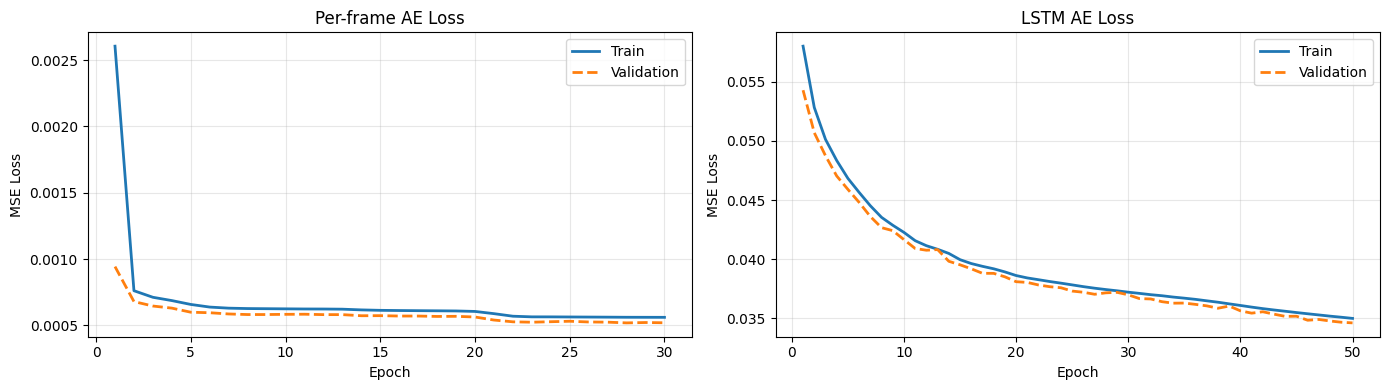

In [10]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, h, t in [(axes[0], history_ae, "Per-frame AE"), (axes[1], history, "LSTM AE")]:
    ax.plot(h["epoch"], h["train_loss"], lw=2, label="Train")
    ax.plot(h["epoch"], h["val_loss"], lw=2, ls="--", label="Validation")
    ax.set(xlabel="Epoch", ylabel="MSE Loss", title=f"{t} Loss")
    ax.legend()
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()